In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
sys.path.insert(0, '../ModelGenerator/huggingface/aido.cell')

from aido_cell.models import CellFoundationConfig
from aido_cell.models.modeling_cellfoundation import CellFoundationForMaskedLM
from aido_cell.utils import align_adata, preprocess_counts

/usr/users/nyanovsky/miniconda3/envs/aido_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
MODEL_NAME = "genbio-ai/AIDO.Cell-100M"
RAW_DATA_FILE = "../data/pbmc/pbmc3k_raw.h5ad"
PROCESSED_DATA_FILE = "../data/pbmc/pbmc3k_processed.h5ad"
OUTPUT_DIR = "../data/pbmc"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

STEERING_LAYER = 15  # Layer to apply steering (1-indexed, so layer index 14)
LEARNING_RATE = 0.1
NUM_ITERATIONS = 40
BATCH_SIZE = 2
LOSS_TYPE = "MSE"

In [4]:
print("\n" + "="*60)
print("AIDO.Cell Contrastive Embedding Steering")
print("="*60)
print(f"Model: {MODEL_NAME}")
print(f"Steering layer: {STEERING_LAYER}")
print("Objective: Move B-cells toward monocyte centroid in embedding space")
print("="*60 + "\n")

# Load processed data for cell type annotations
print("Loading processed data for cell type annotations...")
adata_processed = ad.read_h5ad(PROCESSED_DATA_FILE)
print(f"Processed data shape: {adata_processed.shape}")


AIDO.Cell Contrastive Embedding Steering
Model: genbio-ai/AIDO.Cell-100M
Steering layer: 15
Objective: Move B-cells toward monocyte centroid in embedding space

Loading processed data for cell type annotations...
Processed data shape: (2638, 1838)


/usr/users/nyanovsky/miniconda3/envs/aido_env/lib/python3.10/site-packages/anndata/compat/__init__.py:358: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/usr/users/nyanovsky/miniconda3/envs/aido_env/lib/python3.10/site-packages/anndata/compat/__init__.py:358: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


In [5]:
if 'louvain' in adata_processed.obs.columns:
    cell_types = adata_processed.obs['louvain']
else:
    raise ValueError("No cell type annotation found. Expected 'louvain' column.")

# Load raw data for model input
print("Loading raw data...")
adata_raw = ad.read_h5ad(RAW_DATA_FILE)
print(f"Raw data shape: {adata_raw.shape}")

# Find common cells between raw and processed
common_cells = adata_raw.obs_names.intersection(adata_processed.obs_names)
print(f"Common cells: {len(common_cells)}")

# Filter raw data to common cells and get cell types for those cells
adata_raw = adata_raw[common_cells].copy()
cell_types = cell_types.loc[common_cells]

Loading raw data...
Raw data shape: (2700, 32738)
Common cells: 2638


In [6]:
adata_aligned, attention_mask = align_adata(adata_raw)
print(f"Aligned data shape: {adata_aligned.shape}")
adata_aligned.obs["cell_type"] = cell_types.values

###########  Aligning data to AIDO.Cell  ###########
AIDO.Cell was pretrained on a fixed set of 19264 genes.
Aligning your data to the AIDO.Cell gene set...
15043 in your data that cannot be used by AIDO.Cell. Removing these.
['5S_rRNA' '7SK' '7SK-1' ... 'hsa-mir-7515' 'hsa-mir-8072' 'snoU13']
1569 genes in the AIDO.Cell pretraining set missing in your data.
AIDO.Cell is trained with zero-masking. Setting these to zero for AIDO.Cell to ignore.
['AARS1' 'ABHD18' 'ABITRAM' ... 'ZSCAN26' 'ZSWIM9' 'ZUP1']
17695 non-zero genes remaining.
Reordering genes to match AIDO.Cell gene ordering
Gathering attention mask for nonzero genes
####################  Finished  ####################
Aligned data shape: (2638, 19264)


/tmp/ipykernel_1573399/1516271690.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_aligned.obs["cell_type"] = cell_types.values


In [7]:
b_cell_mask = adata_aligned.obs["cell_type"] == "B cells"
b_cell_mask = b_cell_mask.values

mono_mask = adata_aligned.obs["cell_type"] == "CD14+ Monocytes"
mono_mask = mono_mask.values

print(f"B-cells: {b_cell_mask.sum()}")
print(f"CD14+ Monocytes: {mono_mask.sum()}")

B-cells: 342
CD14+ Monocytes: 480


In [8]:
print(f"\nLoading model: {MODEL_NAME}")
config = CellFoundationConfig.from_pretrained(MODEL_NAME)
model = CellFoundationForMaskedLM.from_pretrained(MODEL_NAME, config=config)
model = model.to(DEVICE)

if DEVICE == "cuda":
    model = model.to(torch.bfloat16)

# Freeze all model parameters
for param in model.parameters():
    param.requires_grad = False

model.eval()
print("Model loaded and frozen")


Loading model: genbio-ai/AIDO.Cell-100M


/usr/users/nyanovsky/miniconda3/envs/aido_env/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model loaded and frozen


In [9]:
class SteerableCellFoundation(nn.Module):
    """Wrapper around CellFoundationForMaskedLM with steering at a specific layer."""

    def __init__(self, model, steering_layer_idx, hidden_size, steering_vector=None):
        super().__init__()
        self.model = model
        self.steering_layer_idx = steering_layer_idx  # 0-indexed
        self.hidden_size = hidden_size

        if steering_vector is not None:
            self.steering_vector = nn.Parameter(steering_vector)
        else:
            self.steering_vector = nn.Parameter(torch.zeros(hidden_size))

        self.hook_handle = None
        self._register_hook()

    def _register_hook(self):
        def steering_hook(module, input, output):
            hidden_states = output[0]
            steered_states = hidden_states + self.steering_vector.to(hidden_states.dtype)
            return (steered_states,) + output[1:]

        layer = self.model.bert.encoder.layer[self.steering_layer_idx]
        self.hook_handle = layer.register_forward_hook(steering_hook)

    def forward(self, input_ids, attention_mask, output_embeddings_only=False):
        """
        Args:
            output_embeddings_only (bool): If True, runs only the encoder (Backbone)
                                           and returns last_hidden_state.
        """
        if output_embeddings_only:
            # Run ONLY the BERT backbone (Encoder), skipping the LM Head
            # This triggers your steering hook but avoids the memory-heavy decoding
            outputs = self.model.bert(
                input_ids=input_ids, 
                attention_mask=attention_mask, 
                return_dict=True
            )
            return outputs.last_hidden_state
        else:
            # Run full model (Encoder + Head)
            return self.model(
                input_ids=input_ids, 
                attention_mask=attention_mask, 
                return_dict=True
            )

    def remove_hook(self):
        if self.hook_handle is not None:
            self.hook_handle.remove()

In [ ]:
# Get hidden size from config
hidden_size = config.hidden_size
print(f"Hidden size: {hidden_size}")

# Prepare attention mask
n_genes = adata_aligned.shape[1]
attn_mask_tensor = torch.from_numpy(attention_mask).unsqueeze(0).to(DEVICE)

# check if pre-steer embeddings exist at ../data/pbmc
pre_steer_emb_path = f"{OUTPUT_DIR}/aido_cell_pre_steer_embeddings.pt"
if os.path.exists(pre_steer_emb_path):
    print(f"Loading pre-steer embeddings from {pre_steer_emb_path}...")
    cell_embeddings = torch.load(pre_steer_emb_path)
    adata_aligned.obsm["pre_steer_emb"] = cell_embeddings
    print(f"Pre-steer embeddings shape: {cell_embeddings.shape}")

else:
    # Compute pre-steer embeddings for ALL cells
    print("Computing pre-steer embeddings for all cells...")
    cell_embeddings = []

    hidden_states = {}

    def capture_hook(module, input, output):
        hidden_states['last_hidden_state'] = output

    hook_handle = model.bert.encoder.ln.register_forward_hook(capture_hook)

    try:
        with torch.no_grad():
            for i in tqdm(range(0, adata_aligned.n_obs, BATCH_SIZE), desc="Computing embeddings"):
                batch_counts = adata_aligned[i:i+BATCH_SIZE].X.toarray()

                batch_processed = preprocess_counts(batch_counts, device=DEVICE)
                batch_attn_mask = attn_mask_tensor.repeat(batch_processed.shape[0], 1)
                depth_token_mask = torch.ones((batch_processed.shape[0], 2), device=DEVICE)
                batch_attn_mask = torch.cat([batch_attn_mask, depth_token_mask], dim=1)

                outputs = model(input_ids=batch_processed, attention_mask=batch_attn_mask, return_dict=True)

                last_hidden_states = hidden_states["last_hidden_state"][:, :-2, :]
                last_hidden_states = last_hidden_states[:, attention_mask.astype(bool), :]

                cell_embeddings.append(last_hidden_states.mean(dim=1).float().cpu().numpy())
    finally:
        hook_handle.remove()

    cell_embeddings = np.concatenate(cell_embeddings, axis=0)
    adata_aligned.obsm["pre_steer_emb"] = cell_embeddings
    print(f"Pre-steer embeddings shape: {cell_embeddings.shape}")

Hidden size: 640
Computing pre-steer embeddings for all cells...


Computing embeddings: 100%|██████████| 660/660 [18:52<00:00,  1.72s/it]

Pre-steer embeddings shape: (2638, 640)


In [10]:
cell_embeddings = torch.load("../data/pbmc/aido_cell_pre_steer_embeddings.pt")
adata_aligned.obsm["pre_steer_emb"] = cell_embeddings

In [14]:
# Compute monocyte centroid (fixed reference point)
mono_centroid = cell_embeddings[mono_mask].mean(axis=0)
mono_centroid_tensor = torch.tensor(mono_centroid, device=DEVICE, dtype=torch.float32)

# Also compute pre-steer B-cell distances for reference
bcell_pre_emb = cell_embeddings[b_cell_mask]
dist_pre = np.linalg.norm(bcell_pre_emb - mono_centroid, axis=1)
print(f"\nPre-steer B-cell to monocyte centroid distance: {dist_pre.mean():.4f} +/- {dist_pre.std():.4f}")

# pre-steer cosine distance 
cos_dists_pre = F.cosine_similarity(torch.tensor(bcell_pre_emb), mono_centroid_tensor.cpu().unsqueeze(0), dim=1)
print(f"Pre-steer B-cell to monocyte centroid cosine distance: {(1-cos_dists_pre).mean()}")


Pre-steer B-cell to monocyte centroid distance: 1.4616 +/- 0.3175
Pre-steer B-cell to monocyte centroid cosine distance: 0.0031983668450266123


In [15]:
hidden_size = config.hidden_size
print(f"Hidden size: {hidden_size}")

# Prepare attention mask
n_genes = adata_aligned.shape[1]
attn_mask_tensor = torch.from_numpy(attention_mask).unsqueeze(0).to(DEVICE)

Hidden size: 640


In [16]:
# Get B-cell raw counts
bcell_raw_counts = adata_aligned.X[b_cell_mask]
if hasattr(bcell_raw_counts, 'toarray'):
    bcell_raw_counts = bcell_raw_counts.toarray()

n_bcells = bcell_raw_counts.shape[0]

# Initialize steerable model
steerable_model = SteerableCellFoundation(
    model,
    steering_layer_idx=STEERING_LAYER - 1,  # Convert to 0-indexed
    hidden_size=hidden_size
)
steerable_model = steerable_model.to(DEVICE)

# Optimizer for steering vector only
optimizer = torch.optim.Adam([steerable_model.steering_vector], lr=0.1)
print(f"Steerable model initialized")
print(f"Number of B-cells to steer: {n_bcells}")

Steerable model initialized
Number of B-cells to steer: 342


In [ ]:
print(f"\nOptimizing steering vector with CONTRASTIVE EMBEDDING LOSS...")
print(f"Iterations: {NUM_ITERATIONS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Target: Minimize B-cell distance to monocyte centroid")

losses = []
mean_distances = []

n_batches = (n_bcells + BATCH_SIZE - 1) // BATCH_SIZE

# Hook to capture steered hidden states during optimization
for iteration in tqdm(range(NUM_ITERATIONS), desc="Optimizing"):
    optimizer.zero_grad()

    total_loss = 0.0
    all_distances = []

    for batch_idx in range(n_batches):
        start_idx = batch_idx * BATCH_SIZE
        end_idx = min(start_idx + BATCH_SIZE, n_bcells)
        batch_counts = bcell_raw_counts[start_idx:end_idx]
        batch_size_actual = batch_counts.shape[0]

        # Preprocess B-cell counts
        batch_processed = preprocess_counts(batch_counts, device=DEVICE)

        # Expand attention mask
        batch_attn_mask = attn_mask_tensor.repeat(batch_processed.shape[0], 1)
        depth_token_mask = torch.ones((batch_processed.shape[0], 2), device=DEVICE)
        batch_attn_mask = torch.cat([batch_attn_mask, depth_token_mask], dim=1)

        # Forward pass with steering
        steerable_model.steering_vector.requires_grad_(True)
        steered_hidden = steerable_model(
            input_ids=batch_processed,
            attention_mask=batch_attn_mask,
            output_embeddings_only=True
        )

        # Get steered embeddings from hook
        steered_hidden = steered_hidden[:, :-2, :]
        steered_hidden = steered_hidden[:, attention_mask.astype(bool), :]
        steered_emb = steered_hidden.mean(dim=1).float()  # [batch, 640]

        # Contrastive loss: minimize distance to monocyte centroid
        if LOSS_TYPE == "cosine":
            # Cosine distance = 1 - cosine_similarity
            cos_sim = F.cosine_similarity(steered_emb, mono_centroid_tensor.unsqueeze(0), dim=1)
            emb_loss = (1 - cos_sim).mean()
        else:  # MSE
            emb_loss = F.mse_loss(steered_emb, mono_centroid_tensor.expand(batch_size_actual, -1))

        # Scale loss by batch proportion for gradient accumulation
        batch_loss = emb_loss * (batch_size_actual / n_bcells)
        batch_loss.backward()

        total_loss += batch_loss.item()

        # Track distances
        with torch.no_grad():
            batch_distances = torch.norm(steered_emb - mono_centroid_tensor, dim=1)
            all_distances.extend(batch_distances.cpu().numpy())

    # Update steering vector
    optimizer.step()

    # Record metrics
    mean_dist = np.mean(all_distances)
    losses.append(total_loss)
    mean_distances.append(mean_dist)

    if (iteration + 1) % 5 == 0 or iteration == 0:
        print(f"  Iter {iteration+1}: Loss={total_loss:.4f}, Mean dist to mono={mean_dist:.4f}")

print("\nOptimization complete!")
print(f"Initial mean distance: {mean_distances[0]:.4f}")
print(f"Final mean distance: {mean_distances[-1]:.4f}")
print(f"Distance change: {mean_distances[-1] - mean_distances[0]:.4f}")


Optimizing steering vector with CONTRASTIVE EMBEDDING LOSS...
Iterations: 40
Learning rate: 0.1
Batch size: 2
Target: Minimize B-cell distance to monocyte centroid


Optimizing:   2%|▎         | 1/40 [03:19<2:09:38, 199.46s/it]

  Iter 1: Loss=0.0035, Mean dist to mono=1.4616


Optimizing:  12%|█▎        | 5/40 [16:44<1:57:12, 200.92s/it]

  Iter 5: Loss=0.0019, Mean dist to mono=1.0569


...

Optimizing:  88%|████████▊ | 35/40 [1:57:29<16:48, 201.67s/it]

  Iter 35: Loss=0.0011, Mean dist to mono=0.7635


Optimizing: 100%|██████████| 40/40 [2:14:18<00:00, 201.46s/it]

  Iter 40: Loss=0.0011, Mean dist to mono=0.7458


NameError: name 'hook_handle' is not defined

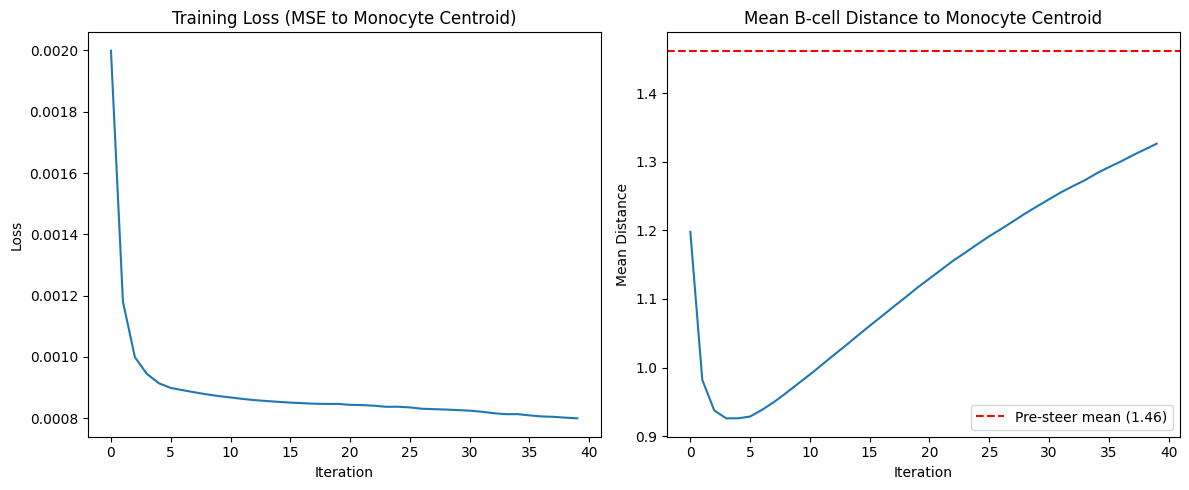

In [18]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(losses)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (MSE to Monocyte Centroid)')

axes[1].plot(mean_distances)
axes[1].axhline(y=dist_pre.mean(), color='r', linestyle='--', label=f'Pre-steer mean ({dist_pre.mean():.2f})')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Mean Distance')
axes[1].set_title('Mean B-cell Distance to Monocyte Centroid')
axes[1].legend()

plt.tight_layout()
#plt.savefig('../plots/contrastive_training_curves.png', dpi=150)
plt.show()

In [19]:
print("\nCollecting steered cell embeddings...")

steered_cell_embeddings = []


# Register hook on the final layer norm

with torch.no_grad():
    for i in tqdm(range(0, adata_aligned.n_obs, BATCH_SIZE), desc="Collecting steered embeddings"):
        batch_counts = adata_aligned[i:i+BATCH_SIZE].X.toarray()

        batch_processed = preprocess_counts(batch_counts, device=DEVICE)
        batch_attn_mask = attn_mask_tensor.repeat(batch_processed.shape[0], 1)
        depth_token_mask = torch.ones((batch_processed.shape[0], 2), device=DEVICE)
        batch_attn_mask = torch.cat([batch_attn_mask, depth_token_mask], dim=1)

        # Forward pass WITH steering
        outputs = steerable_model(
                input_ids=batch_processed,
                attention_mask=batch_attn_mask,
                output_embeddings_only=True
            )

        # Get the captured hidden state from hook
        last_hidden_steered = outputs[:, :-2, :]
        last_hidden_steered = last_hidden_steered[:, attention_mask.astype(bool), :]
        steered_cell_embeddings.append(last_hidden_steered.mean(dim=1).float().cpu().numpy())

steered_cell_embeddings = np.concatenate(steered_cell_embeddings, axis=0)
adata_aligned.obsm["post_steer_emb"] = steered_cell_embeddings
print(f"Steered embeddings shape: {steered_cell_embeddings.shape}")

Steered embeddings shape: (2638, 640)


In [ ]:
# Distance Analysis: Quantify B-cell to Monocyte movement
from scipy import stats

# Get embeddings
bcell_pre_emb = adata_aligned.obsm["pre_steer_emb"][b_cell_mask]
bcell_post_emb = adata_aligned.obsm["post_steer_emb"][b_cell_mask]

# Compute Euclidean distance from each B-cell to monocyte centroid
dist_pre = np.linalg.norm(bcell_pre_emb - mono_centroid, axis=1)
dist_post = np.linalg.norm(bcell_post_emb - mono_centroid, axis=1)

# Compute cosine distance from each B-cell to monocyte centroid
# dist_pre = 1-F.cosine_similarity(torch.tensor(bcell_pre_emb), mono_centroid_tensor.cpu().unsqueeze(0), dim=1)
# dist_post = 1-F.cosine_similarity(torch.tensor(bcell_post_emb), mono_centroid_tensor.cpu().unsqueeze(0), dim=1)

# Print statistics
print("="*60)
print("Distance Analysis: B-cells to Monocyte Centroid")
print("="*60)
print(f"\nPre-steer distance:  {dist_pre.mean():.4f} +/- {dist_pre.std():.4f}")
print(f"Post-steer distance: {dist_post.mean():.4f} +/- {dist_post.std():.4f}")
print(f"\nMean change: {(dist_post - dist_pre).mean():.4f}")
print(f"Median change: {np.median(dist_post - dist_pre):.4f}")

# Percentage of B-cells that moved closer to monocytes
moved_closer = (dist_post < dist_pre).sum()
total_bcells = len(dist_pre)
print(f"\nB-cells that moved closer: {moved_closer}/{total_bcells} ({100*moved_closer/total_bcells:.1f}%)")

# Paired t-test
t_stat, p_value = stats.ttest_rel(dist_pre, dist_post)
print(f"\nPaired t-test: t={t_stat:.4f}, p={p_value:.2e}")

Distance Analysis: B-cells to Monocyte Centroid

Pre-steer distance:  0.0032 +/- 0.0016
Post-steer distance: 0.0008 +/- 0.0008

Mean change: -0.0024
Median change: -0.0022

B-cells that moved closer: 336/342 (98.2%)

Paired t-test: t=33.3954, p=1.57e-109


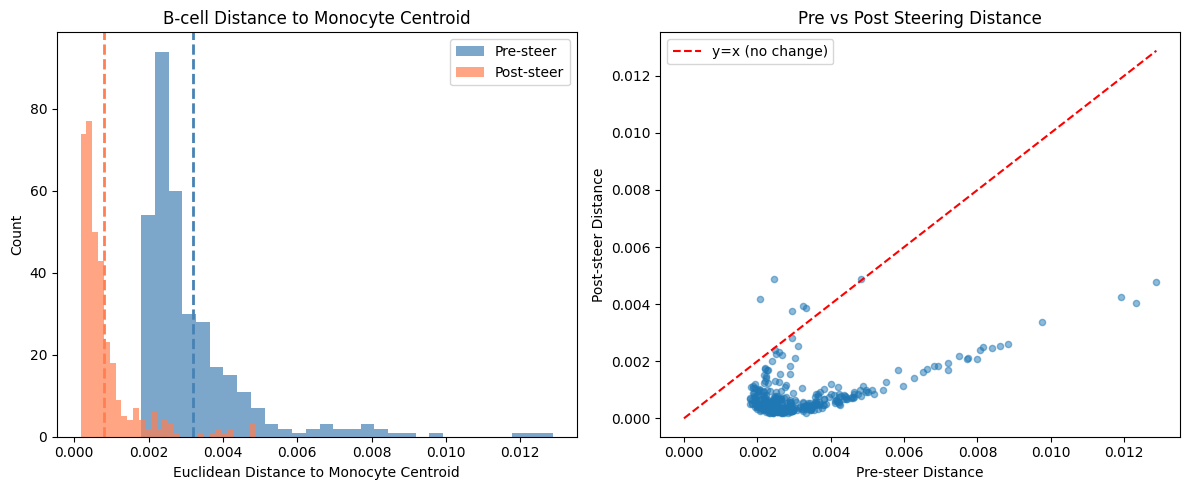

In [29]:
# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of distances
axes[0].hist(dist_pre, bins=30, alpha=0.7, label='Pre-steer', color='steelblue')
axes[0].hist(dist_post, bins=30, alpha=0.7, label='Post-steer', color='coral')
axes[0].axvline(dist_pre.mean(), color='steelblue', linestyle='--', linewidth=2)
axes[0].axvline(dist_post.mean(), color='coral', linestyle='--', linewidth=2)
axes[0].set_xlabel('Euclidean Distance to Monocyte Centroid')
axes[0].set_ylabel('Count')
axes[0].set_title('B-cell Distance to Monocyte Centroid')
axes[0].legend()

# Scatter plot: pre vs post distance
axes[1].scatter(dist_pre, dist_post, alpha=0.5, s=20)
max_dist = max(dist_pre.max(), dist_post.max())
axes[1].plot([0, max_dist], [0, max_dist], 'r--', label='y=x (no change)')
axes[1].set_xlabel('Pre-steer Distance')
axes[1].set_ylabel('Post-steer Distance')
axes[1].set_title('Pre vs Post Steering Distance')
axes[1].legend()

plt.tight_layout()
plt.savefig('../plots/contrastive_distance_analysis.png', dpi=150)
plt.show()

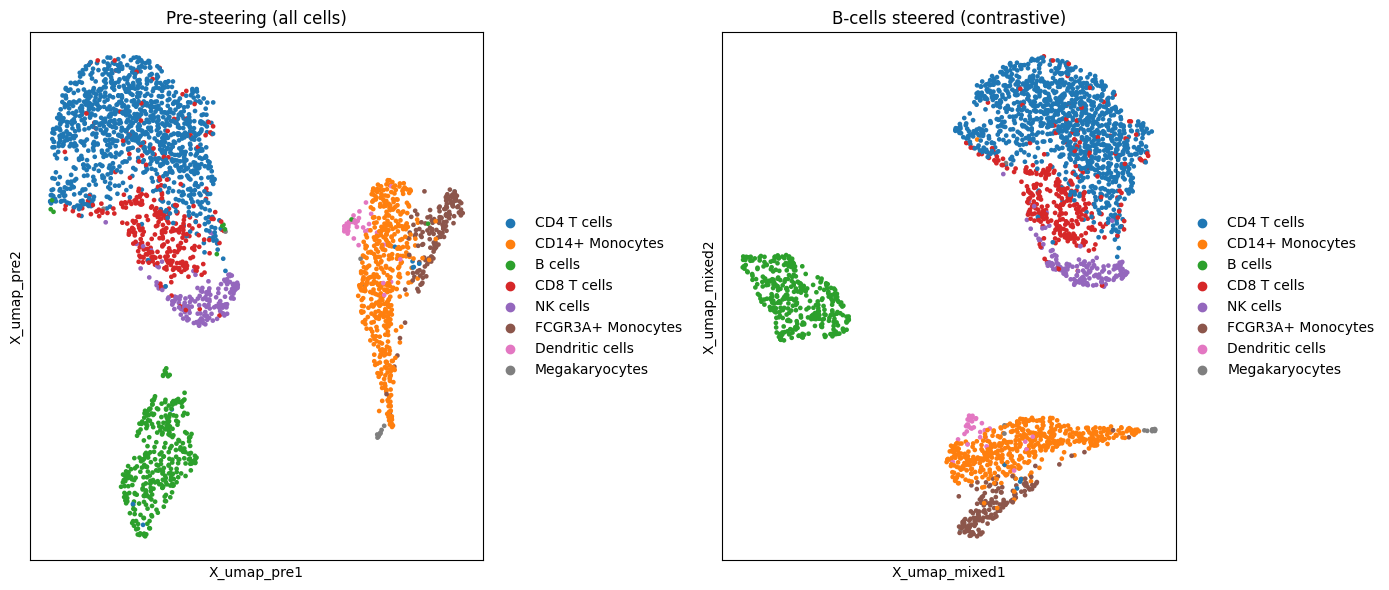

In [24]:
import scanpy as sc

# Create mixed embeddings: pre-steer for all except B-cells, post-steer for B-cells
mixed_embeddings = adata_aligned.obsm["pre_steer_emb"].copy()
mixed_embeddings[b_cell_mask] = steered_cell_embeddings[b_cell_mask]
adata_aligned.obsm["mixed_steer_emb"] = mixed_embeddings

# Compute UMAP for pre-steer embeddings
sc.pp.neighbors(adata_aligned, use_rep="pre_steer_emb", key_added="pre_steer")
sc.tl.umap(adata_aligned, neighbors_key="pre_steer")
adata_aligned.obsm["X_umap_pre"] = adata_aligned.obsm["X_umap"].copy()

# Compute UMAP for mixed embeddings (B-cells steered, others not)
sc.pp.neighbors(adata_aligned, use_rep="mixed_steer_emb", key_added="mixed_steer")
sc.tl.umap(adata_aligned, neighbors_key="mixed_steer")
adata_aligned.obsm["X_umap_mixed"] = adata_aligned.obsm["X_umap"].copy()

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.embedding(adata_aligned, basis="X_umap_pre", color="cell_type", ax=axes[0], show=False, title="Pre-steering (all cells)")
sc.pl.embedding(adata_aligned, basis="X_umap_mixed", color="cell_type", ax=axes[1], show=False, title="B-cells steered (contrastive)")
plt.tight_layout()
plt.savefig('../plots/contrastive_umap_bcell_steering.png', dpi=150)
plt.show()

In [24]:
# Save contrastive steering vector
steering_vector_path = os.path.join(OUTPUT_DIR, "contrastive_steering_vector.pt")
torch.save(steerable_model.steering_vector.data.cpu(), steering_vector_path)
print(f"\nContrastive steering vector saved to: {steering_vector_path}")

# Clean up
steerable_model.remove_hook()


Contrastive steering vector saved to: ../data/pbmc/contrastive_steering_vector.pt
